## How to use this notebook

- **Single-run cells**: The first few code cells run one simulation each for the sequential, standard, and parallel processes and drive the Gantt / single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` run many simulations per process and feed the aggregate statistics and comparison plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block to update the aggregate visualizations.

In [1]:
from run_simulation import run_simulation, print_statistics, run_multiple_simulations
from visualize_permits import (
    visualize_all,
    plot_median_total_time_by_process,
    plot_gantt_one_random_permit_segment,
)
import matplotlib.pyplot as plt
import numpy as np

# Common parameters for both analyses
NUM_PERMITS = 6410
RANDOM_SEED = 42
INTER_ARRIVAL_TIME = 0.0  # run permits back-to-back


In [2]:
# Run all three simulations
print(f"Running sequential simulation with {NUM_PERMITS} permits...")
sim_sequential = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="sequential",
)

print(f"\nRunning standard simulation with {NUM_PERMITS} permits...")
sim_standard = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="standard",
)

print(f"\nRunning parallel simulation with {NUM_PERMITS} permits...")
sim_parallel = run_simulation(
    num_permits=NUM_PERMITS,
    random_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    sequential="parallel",
)

Running sequential simulation with 6410 permits...

Running standard simulation with 6410 permits...

Running parallel simulation with 6410 permits...


In [3]:
# Print statistics for each process
print("=== SEQUENTIAL PROCESS ===")
stats_sequential = sim_sequential.get_statistics()
print_statistics(stats_sequential)

print("=== STANDARD PROCESS ===")
stats_standard = sim_standard.get_statistics()
print_statistics(stats_standard)

print("\n=== PARALLEL PROCESS ===")
stats_parallel = sim_parallel.get_statistics()
print_statistics(stats_parallel)


=== SEQUENTIAL PROCESS ===

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4630 (72.23%)
  CUSTOM_NON_LIKE               : 1148 (17.91%)
  PRE_APPROVED_LIKE             :   93 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.33%)
  SELF_CERT_LIKE                :  425 ( 6.63%)
  SELF_CERT_NON_LIKE            :   93 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     450.23 days
  Median:   432.67 days
  Std Dev:  137.25 days
  Min:      160.19 days
  Max:     2573.70 days

--------------------------------------------------------------------------------
PROCESSING TIME BY SEGMENT

In [4]:
# Run multiple simulations for each process configuration to see aggregate behavior
n_runs = 100

scenario_params_list = [
    {"name": "Sequential", "sequential": "sequential"},
    {"name": "Standard", "sequential": "standard"},
    {"name": "Parallel", "sequential": "parallel"},
]

multi_results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=NUM_PERMITS,
    simulation_duration=None,
    base_seed=RANDOM_SEED,
    inter_arrival_time=INTER_ARRIVAL_TIME,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

all_sequential_permits: list = []
all_standard_permits: list = []
all_parallel_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Sequential":
        all_sequential_permits.extend(permits)
    elif scenario == "Standard":
        all_standard_permits.extend(permits)
    elif scenario == "Parallel":
        all_parallel_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {n_runs} runs per process (sequential / standard / parallel). Aggregate total-time stats:")
_print_summary("Sequential", all_sequential_permits)
_print_summary("Standard", all_standard_permits)
_print_summary("Parallel", all_parallel_permits)

Ran 100 runs per process (sequential / standard / parallel). Aggregate total-time stats:
Sequential: n=641000, mean=448.70, median=432.86
Standard: n=641000, mean=325.32, median=309.82
Parallel: n=641000, mean=239.36, median=215.27


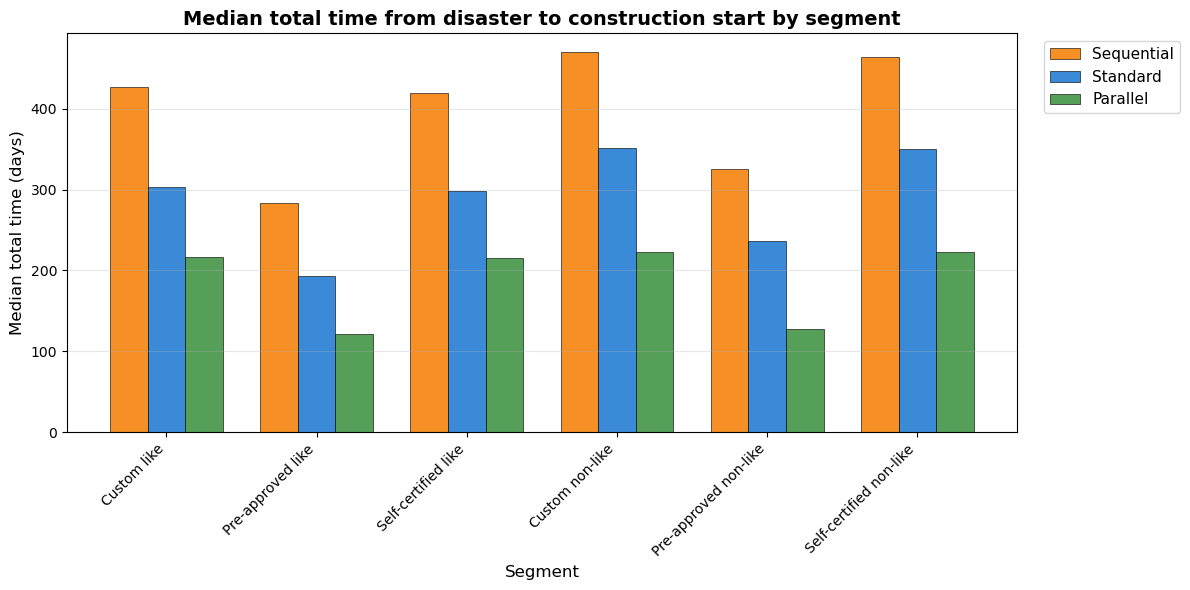

In [5]:
# Compare median total time (disaster to construction) by segment
# Use aggregated permits across many runs for each process
permits_by_process = {
    "Sequential": all_sequential_permits,
    "Standard": all_standard_permits,
    "Parallel": all_parallel_permits,
}
fig, ax = plot_median_total_time_by_process(permits_by_process)
if fig is not None:
    plt.show()


SEQUENTIAL process – Segment 4 permit


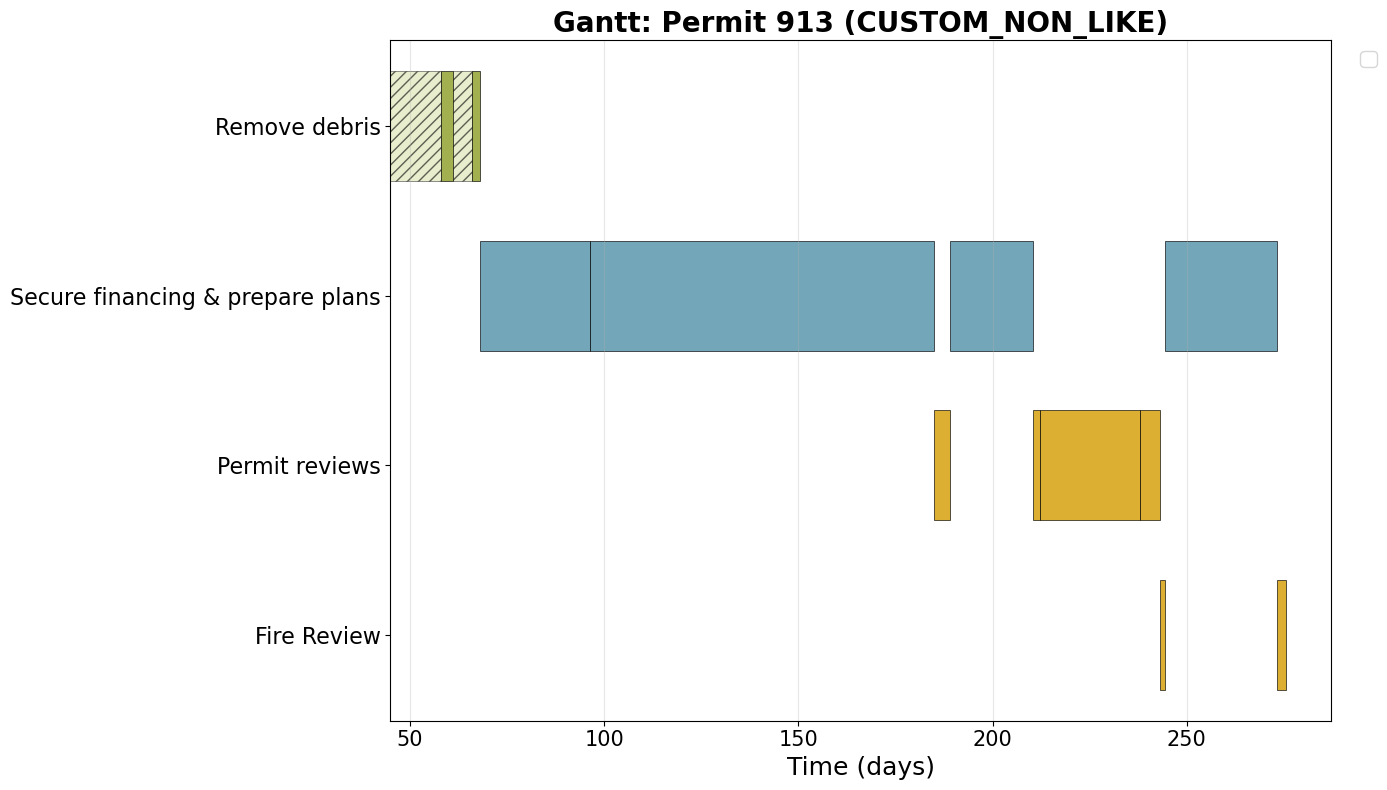


STANDARD process – Segment 4 permit


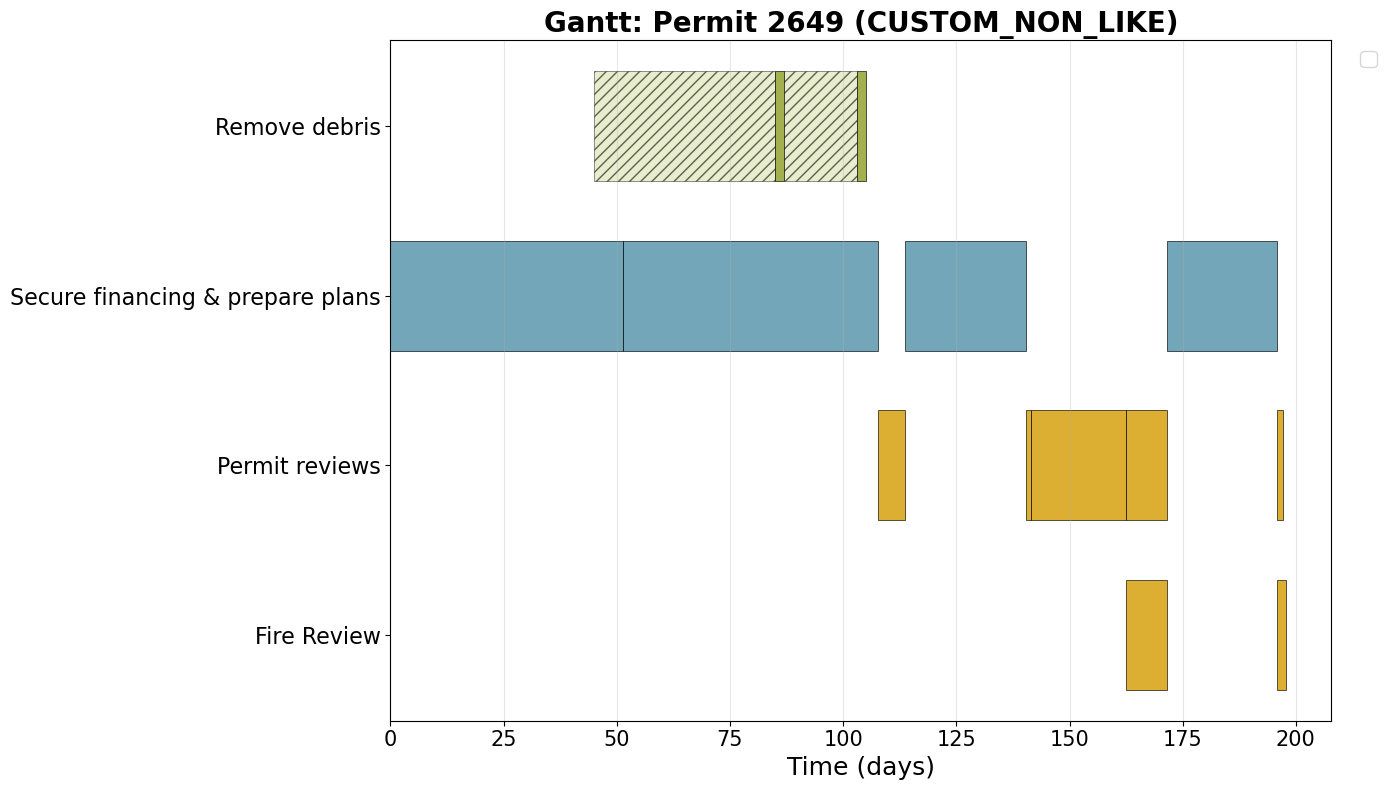


PARALLEL process – Segment 4 permit


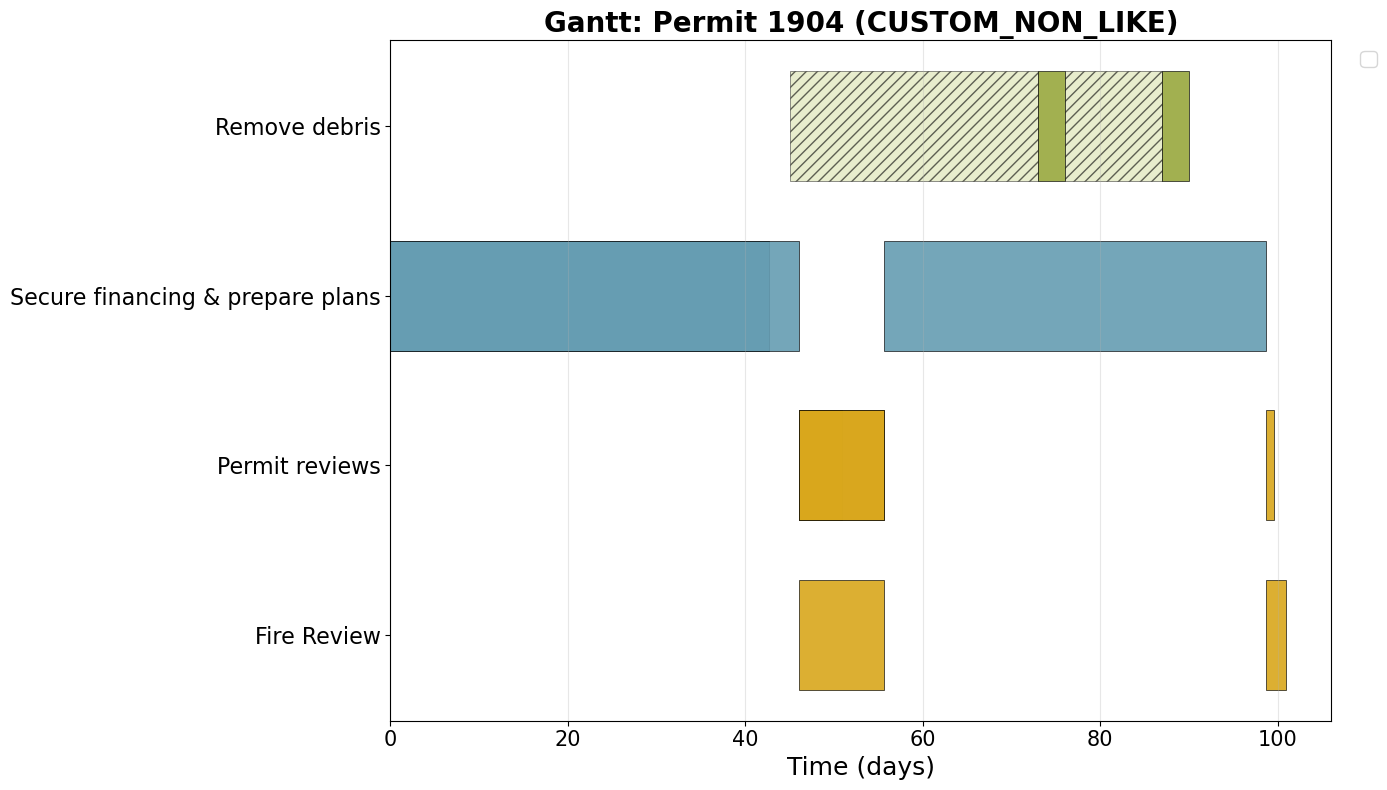

In [6]:
# Gantt charts for one random Segment 4 permit under each process
print("SEQUENTIAL process – Segment 4 permit")
fig1, ax1 = plot_gantt_one_random_permit_segment(
    sim_sequential.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig1 is not None:
    plt.show()

print("\nSTANDARD process – Segment 4 permit")
fig2, ax2 = plot_gantt_one_random_permit_segment(
    sim_standard.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig2 is not None:
    plt.show()

print("\nPARALLEL process – Segment 4 permit")
fig3, ax3 = plot_gantt_one_random_permit_segment(
    sim_parallel.completed_permits,
    segment_value=4,
    random_seed=123,
    figsize=(14, 8),
)
if fig3 is not None:
    plt.show()


Creating visualizations for SEQUENTIAL process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


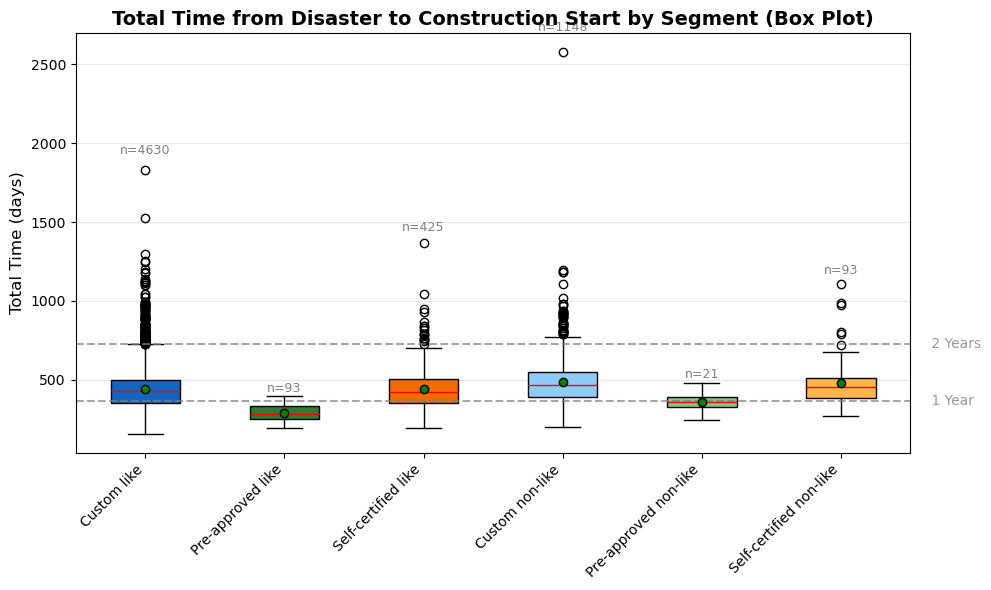

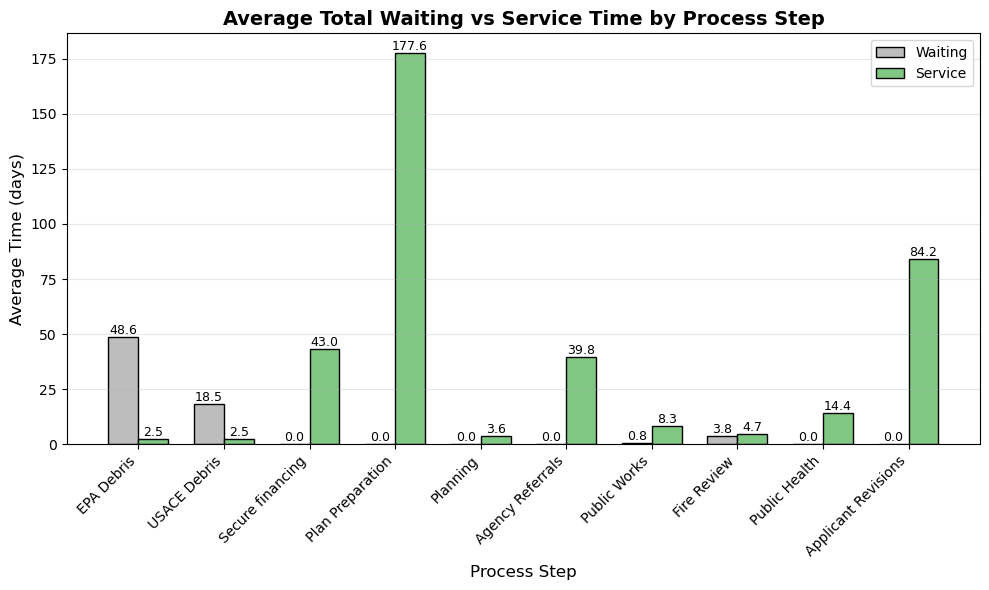

Visualizations complete!


In [7]:
# Full visualization set for each process (mirrors prior single-process notebooks)
print("Creating visualizations for SEQUENTIAL process...")
visualize_all(sim_sequential.completed_permits, save_prefix=None, show=True)



Creating visualizations for STANDARD process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


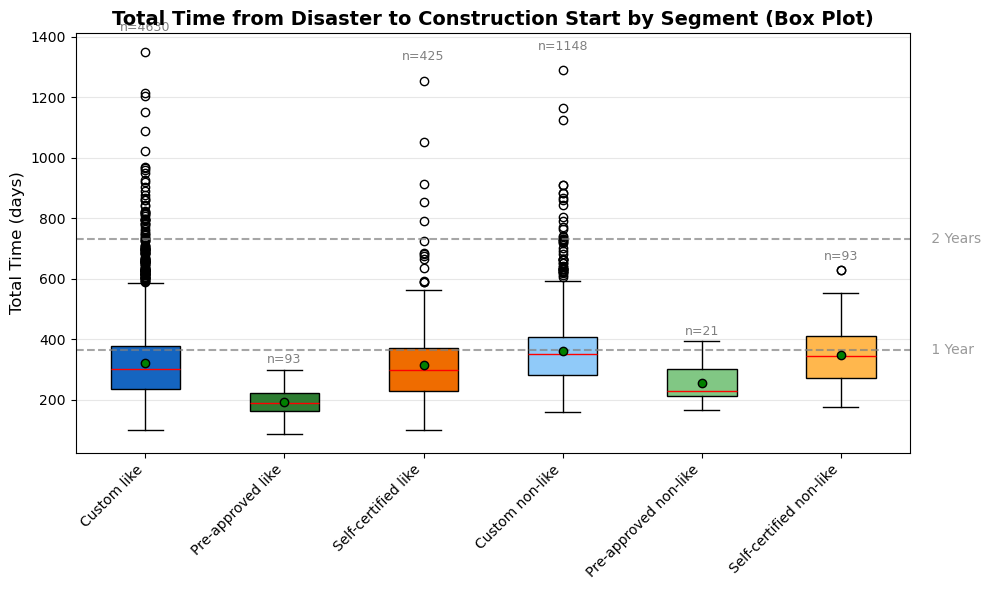

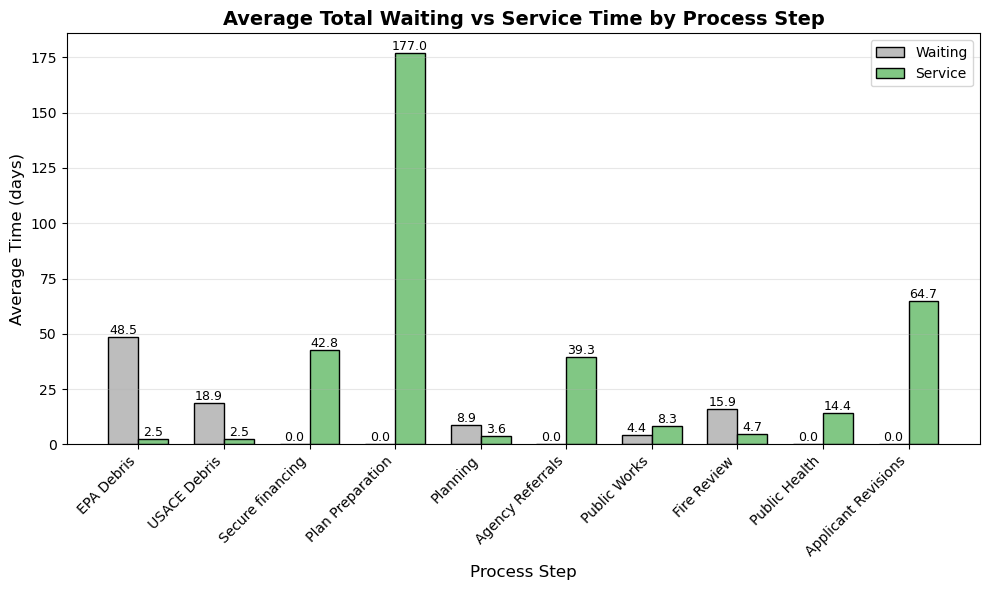

Visualizations complete!


In [8]:
print("\nCreating visualizations for STANDARD process...")
visualize_all(sim_standard.completed_permits, save_prefix=None, show=True)


Creating visualizations for PARALLEL process...
Creating visualizations for 6410 permits...
  Creating total time by segment chart (box plot)...
  Creating waiting vs service by step chart...


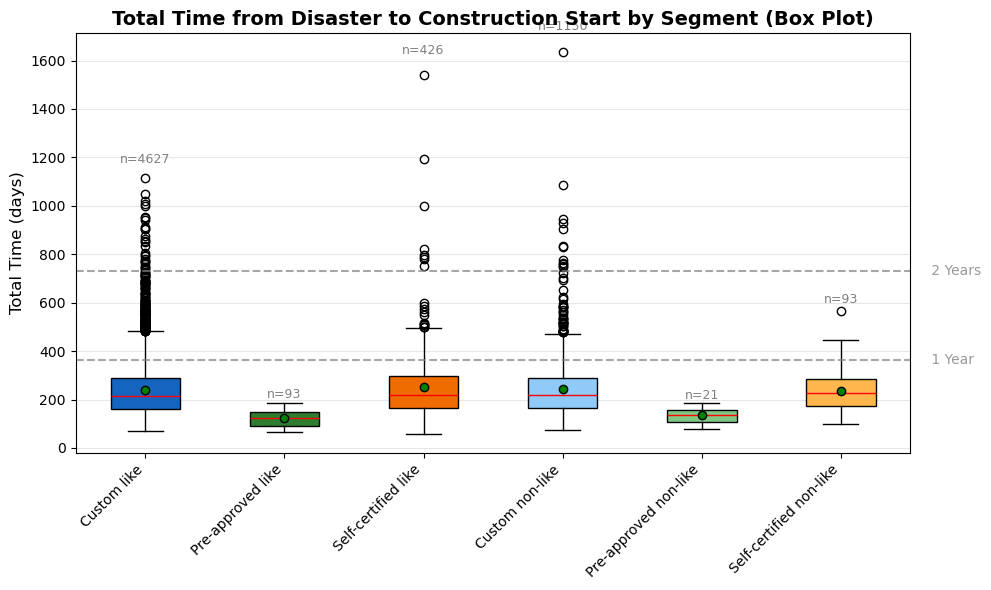

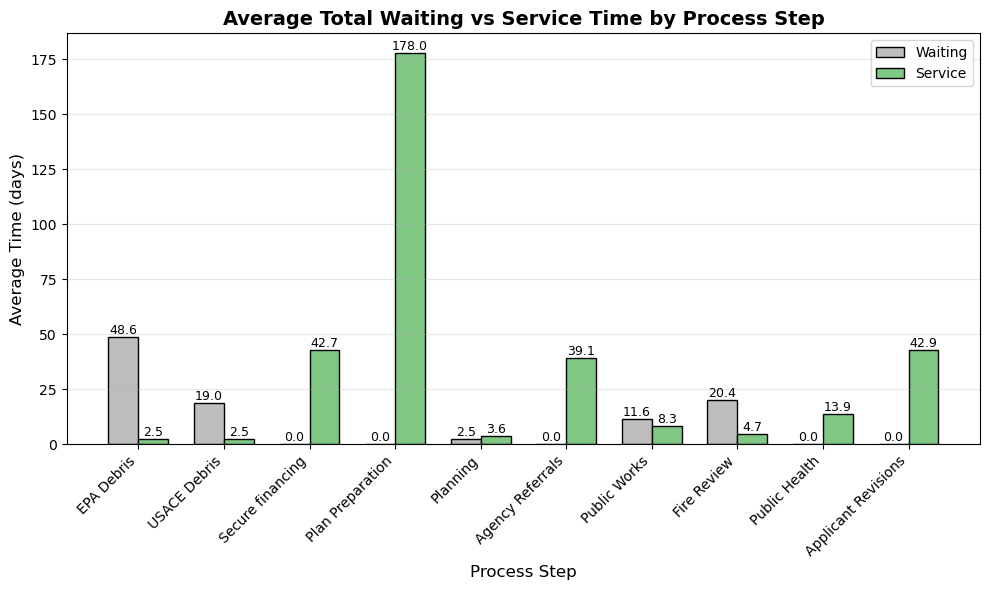

Visualizations complete!


In [9]:
print("\nCreating visualizations for PARALLEL process...")
visualize_all(sim_parallel.completed_permits, save_prefix=None, show=True)